In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!git clone https://github.com/shubham-sahoo/acceleration-flow-matching.git
os.chdir('acceleration-flow-matching')

Cloning into 'acceleration-flow-matching'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 25 (delta 4), reused 20 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 23.90 KiB | 23.90 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [5]:
import sys
sys.path.append("/content/acceleration-flow-matching/src")


In [6]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import BaseViT, PatchEmbedding
from data_loader import train_loader
from tqdm import tqdm
from diffusion import DDPMSampler
from utils import visualize_samples

Model parameters: 5.43M
✓ Model ready


100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


50000


In [7]:
def train_ddpm(model_sampler: DDPMSampler, train_loader, device='cpu', epochs=5, lr=1e-4):
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    num_steps = 1000
    betas = torch.linspace(0.0001, 0.02, num_steps, device=device)
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_1_minus_alpha_bars = torch.sqrt(1 - alpha_bars)

    model_sampler.model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}/{epochs}")

        for batch_idx, (x, _) in enumerate(progress_bar):

            loss = model_sampler.forward_loss(x, num_steps, criterion)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model_sampler.model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - DDPM Loss: {avg_loss:.6f}\n")

    return model_sampler.model

In [11]:
device = 'cuda'
model = BaseViT(img_size=32, patch_size=4, embed_dim=192, depth=12, num_heads=3)
model = model.to(device)

model_ddpm = DDPMSampler(model, device=device)


model = train_ddpm(model_ddpm, train_loader, device=device, epochs=30, lr=1e-4)



DDPM Epoch 1/10: 100%|██████████| 782/782 [01:23<00:00,  9.36it/s, loss=0.127]


Epoch 1 - DDPM Loss: 0.234736



DDPM Epoch 2/10: 100%|██████████| 782/782 [01:23<00:00,  9.41it/s, loss=0.0669]


Epoch 2 - DDPM Loss: 0.080818



DDPM Epoch 3/10: 100%|██████████| 782/782 [01:23<00:00,  9.41it/s, loss=0.0548]


...

Epoch 8 - DDPM Loss: 0.054109



DDPM Epoch 9/10: 100%|██████████| 782/782 [01:23<00:00,  9.42it/s, loss=0.016]


Epoch 9 - DDPM Loss: 0.053478



DDPM Epoch 10/10: 100%|██████████| 782/782 [01:23<00:00,  9.39it/s, loss=0.11]

Epoch 10 - DDPM Loss: 0.052180



In [12]:
torch.save(model.state_dict(), 'ddpm_model.pth')
print("✓ Model saved to ddpm_model.pth")

✓ Model saved to ddpm_model.pth


DDPM: 100%|██████████| 999/999 [00:09<00:00, 102.16it/s]


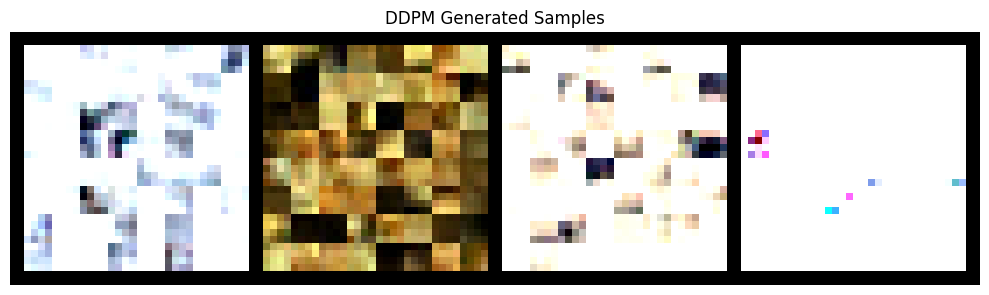

In [17]:
sampler = model_ddpm


# Cell 4: Test and Benchmark

# Generate samples
x_noise = torch.randn(4, 3, 32, 32, device=device)
x_samples = sampler.sample(x_noise, t_steps=999, verbose=True)


# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")